# 3D simple perturbation: first-order Liénard–Wiechert correction

The zeroth-order trajectory is the exact motion of a single charge in the
constant longitudinal external field `E_Z`.  The first-order perturbation
in position and momentum is then obtained by integrating the
Liénard–Wiechert fields produced by all *other* macroparticles along that
zeroth-order trajectory.

## Unit conventions

A hybrid unit system is used for the dynamical variables:

- length          : m
- time            : s
- mass            : MeV / c²
- momentum        : MeV / c
- charge          : units of the elementary-charge magnitude `|e|`
- electric field  : MV / m

`calc_LW_fields` temporarily switches to pure SI (coulombs, volts per
metre, tesla) to evaluate the electromagnetic field formulas; the
returned force is converted back to the hybrid system before being fed
into the state-vector derivative.  Momenta are converted to the
dimensionless `β·γ` only for plotting.

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import qmc
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

plt.rcParams["font.family"] = "serif"

In [28]:
# ---------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------
C_SI         = 299_792_458          # speed of light                    [m/s]
EPSILON_0_SI = 8.8541878128e-12     # vacuum permittivity               [A·s/(V·m)]
E_CHARGE_SI  = 1.602176634e-19      # elementary charge magnitude |e|   [C]
M_E_SI       = 9.1093837015e-31     # electron rest mass                [kg]
M_E          = 0.511                # electron rest mass                [MeV/c²]
Q_E          = -1.0                 # electron charge                   [|e|]

In [29]:
# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------
E_Z              = -1.0             # longitudinal external E-field     [MV/m]
TOTAL_CHARGE_SI  = -1e-9            # total bunch charge                [C]
N_PARTICLES      = 2**7             # number of macroparticles          [1]
T_END_SIMPLE     = 1.2e-8           # end of integration                [s]

# ---------------------------------------------------------------------
# Derived quantities
# ---------------------------------------------------------------------
N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI) / E_CHARGE_SI    # real electrons in the bunch
MACRO_WEIGHT     = N_REAL_PARTICLES / N_PARTICLES           # real particles per macroparticle

# Signed macroparticle charge / mass for the pure-SI L-W field calculation.
Q_MACRO_SI = Q_E * MACRO_WEIGHT * E_CHARGE_SI               # [C]
M_MACRO_SI = MACRO_WEIGHT * M_E_SI                          # [kg]

In [30]:
def p_to_betagamma(p):
    """Convert momentum from [MeV/c] to the dimensionless ``β·γ``.

    Parameters
    ----------
    p : array_like
        Momentum in MeV/c.

    Returns
    -------
    array_like
        Same shape as ``p``, dimensionless.
    """
    return p / M_E


def sample_ellipsoid_qmc(mean, radii, n_particles):
    """Quasi-Monte-Carlo sampling of a 3D ellipsoid using a Sobol sequence.

    Produces a low-discrepancy, clump-free, uniform-density set of points
    inside the ellipsoid centred at ``mean`` with semi-axes ``radii``.

    Parameters
    ----------
    mean : array_like, shape (3,)
        Centre of the ellipsoid [m].
    radii : array_like, shape (3,)
        Semi-axis lengths [m].
    n_particles : int
        Number of samples (best results when this is a power of two).

    Returns
    -------
    points : ndarray, shape (n_particles, 3)
        Sampled positions [m].
    """
    sampler = qmc.Sobol(d=3, scramble=True)
    u = sampler.random(n=n_particles)
    u1, u2, u3 = u[:, 0], u[:, 1], u[:, 2]

    # Uniform density inside the unit ball: r ~ u1^(1/3) absorbs the radial
    # Jacobian; cos(θ) uniform in [-1, 1] gives a uniform direction.
    r         = u1 ** (1.0 / 3.0)
    cos_theta = 1.0 - 2.0 * u2
    sin_theta = np.sqrt(1.0 - cos_theta ** 2)
    phi       = 2.0 * np.pi * u3

    x_sphere = r * sin_theta * np.cos(phi)
    y_sphere = r * sin_theta * np.sin(phi)
    z_sphere = r * cos_theta

    points = np.empty((n_particles, 3))
    points[:, 0] = mean[0] + radii[0] * x_sphere
    points[:, 1] = mean[1] + radii[1] * y_sphere
    points[:, 2] = mean[2] + radii[2] * z_sphere
    return points

In [31]:
# Reference-simulation data.
#   column  0     time           [s]
#   columns 1..3  mean position  (x, y, z)   [m]
#   columns 4..6  position sigma (x, y, z)   [m]
#   columns 7..9  mean momentum  (x, y, z)   [MeV/c]
data_3d_simple = np.loadtxt("./data/3d_data_simple.csv", delimiter=",")

data_times = data_3d_simple[:, 0]
data_position_means_si  = data_3d_simple[:, 1:4]    # [m]
data_position_sigmas_si = data_3d_simple[:, 4:7]    # [m]
data_momentum_means_pp  = data_3d_simple[:, 7:10]   # [MeV/c]
data_momentum_sigmas_pp = data_3d_simple[:, 10:]    # [MeV/c]

def plot_data(ax, x_analytic, y_analytic, x_data, y_data):
    y_data_interp = np.interp(x_analytic, x_data, y_data)

    ax.plot(x_analytic, y_data_interp, label="Simulation Data", color="black", linestyle="--", linewidth=0.5)
    ax.legend(loc="upper left")

    ax_diff = ax.twinx()
    y_diff = np.abs(y_data_interp - y_analytic)
    ax_diff.plot(x_analytic, y_diff, label="Difference \nSimulation - Analytic", color="red", linewidth=0.5)
    ax_diff.set_ylabel(ax.get_ylabel(), color="red")
    ax_diff.tick_params(axis='y', labelcolor="red")
    ax_diff.legend(loc="upper right")

In [32]:
def get_0th_trajectory(t, r0, p0_z):
    """Exact zeroth-order trajectory in the constant external field ``E_Z``.

    Parameters
    ----------
    t : float
        Observation time [s].
    r0 : ndarray, shape (3,)
        Initial position [m].
    p0_z : float
        Initial longitudinal momentum [MeV/c].

    Returns
    -------
    r_t : ndarray, shape (3,)
        Position at ``t``                                 [m].
    pz_t : float
        Longitudinal momentum at ``t``                    [MeV/c].
    gamma_t : float
        Lorentz factor at ``t``                           [1].
    """
    # fsolve passes t as a length-1 array; coerce to scalar.
    t = float(np.atleast_1d(t)[0])

    # Force in hybrid units:  F = Q_E * E_Z * c_SI  has units of [MeV/c per s]
    # (the c_SI factor absorbs the V↔MeV and MV↔V conversions).
    pz_t = p0_z + (Q_E * E_Z * C_SI) * t

    gamma_t = np.sqrt(1.0 + (pz_t / M_E) ** 2)
    gamma_0 = np.sqrt(1.0 + (p0_z / M_E) ** 2)

    # Analytic z-displacement from ∫ v dt with a constant longitudinal force:
    #     Δz = (m c² / F) · (γ(t) - γ(0))
    # which in the same hybrid units collapses to  M_E / (Q_E · E_Z).
    delta_z = (M_E / (Q_E * E_Z)) * (gamma_t - gamma_0)

    r_t = np.array([r0[0], r0[1], r0[2] + delta_z])
    return r_t, pz_t, gamma_t

In [33]:
def t_ret(t_obs, r_obs, r_0_src, pz_0):
    """Retarded time of a source particle for an observer at ``r_obs``, ``t_obs``.

    Solves the light-cone condition

        c · (t_obs - t_r) - |r_obs - r_src(t_r)| = 0.
    """
    def root_eq(t_r):
        r_src_tr, _, _ = get_0th_trajectory(t_r, r_0_src, pz_0)
        distance = np.linalg.norm(r_obs - r_src_tr)
        return C_SI * (t_obs - t_r) - distance

    # Good initial guess: straight-line light travel time to the source's
    # *current* position.
    r_src_curr, _, _ = get_0th_trajectory(t_obs, r_0_src, pz_0)
    curr_distance = np.linalg.norm(r_obs - r_src_curr)
    t_r_guess = t_obs - (curr_distance / C_SI)

    t_r_solution, = fsolve(root_eq, t_r_guess)
    return t_r_solution


# =====================================================================
# Liénard–Wiechert fields (first-order force)
# =====================================================================
def calc_LW_fields(t_obs, r_obs, r_0_src, p_0):
    """Liénard–Wiechert E and B fields produced by one source macroparticle.

    Internally evaluated in pure SI (to avoid having to track all unit
    conversions inside the electromagnetic field expressions); the
    returned fields are in SI as well — volts per metre and tesla — and
    are converted back by the caller.

    Parameters
    ----------
    t_obs : float
        Observer time [s].
    r_obs : ndarray, shape (3,)
        Observer position [m].
    r_0_src : ndarray, shape (3,)
        Initial position of the source particle [m].
    p_0 : float
        Initial longitudinal momentum of the source [MeV/c].

    Returns
    -------
    E_field_si : ndarray, shape (3,)
        Electric field at the observer [V/m].
    B_field_si : ndarray, shape (3,)
        Magnetic field at the observer [T].
    """
    t_r = t_ret(t_obs, r_obs, r_0_src, p_0)
    r_src, pz_src, gamma_src = get_0th_trajectory(t_r, r_0_src, p_0)

    # Geometry.
    R_vec = r_obs - r_src                    # [m]
    R_mag = np.linalg.norm(R_vec)            # [m]
    n_vec = R_vec / R_mag                    # [1]

    # Source kinematics at the retarded time.
    beta_z   = pz_src / (gamma_src * M_E)              # [1]
    beta_vec = np.array([0.0, 0.0, beta_z])            # [1]

    # Longitudinal acceleration in SI:  a_∥ = F / (γ³ m).
    E_ext_si = E_Z * 1e6                                                # [V/m]
    q_elec_si = Q_E * E_CHARGE_SI           # [C]
    m_elec_si = M_E_SI                      # [kg]
    a_z_si = (q_elec_si * E_ext_si) / (m_elec_si * gamma_src**3)  # [m/s²]
    dot_beta_vec = np.array([0.0, 0.0, a_z_si / C_SI])                  # [1/s]

    one_minus_beta_n = 1.0 - np.dot(beta_vec, n_vec)                    # [1]

    # Velocity (near) field: dimension [1/m²].
    term_velocity = (n_vec - beta_vec) / (
        gamma_src ** 2 * one_minus_beta_n ** 3 * R_mag ** 2
    )

    # Acceleration (radiation) field: dimension [1/m²] after the
    # (1/s) / (m/s · m) cancellations.
    cross_accel = np.cross(n_vec - beta_vec, dot_beta_vec)
    term_accel  = np.cross(n_vec, cross_accel) / (
        C_SI * one_minus_beta_n ** 3 * R_mag
    )

    E_field_si = (Q_MACRO_SI / (4.0 * np.pi * EPSILON_0_SI)) * (
        term_velocity + term_accel
    )                                                       # [V/m]
    B_field_si = np.cross(n_vec, E_field_si) / C_SI         # [T]
    return E_field_si, B_field_si


# =====================================================================
# First-order perturbation integrator
# =====================================================================
def get_1st_order_perturbation(t_end, r0_target, all_r0_sources, p0_z):
    """Integrate the first-order position and momentum perturbation.

    Parameters
    ----------
    t_end : float
        Final integration time [s].
    r0_target : ndarray, shape (3,)
        Initial (zeroth-order) position of the target particle [m].
    all_r0_sources : ndarray, shape (N, 3)
        Initial positions of the source macroparticles [m].  The target
        itself is skipped inside the integrand.
    p0_z : float
        Initial longitudinal momentum [MeV/c], shared by all particles.

    Returns
    -------
    t : ndarray
        Adaptive solver time grid [s].
    r1_t : ndarray, shape (3, len(t))
        Position perturbation [m].
    p1_t : ndarray, shape (3, len(t))
        Momentum perturbation [MeV/c].
    """
    # SI→hybrid momentum conversion.  1 MeV/c = 1e6 · |e| / c_SI  kg·m/s, so
    #     dp_hybrid/dt  =  F_SI / p_si_per_hybrid    [MeV/c per s].
    p_si_per_hybrid = (1e6 * E_CHARGE_SI) / C_SI         # [kg·m/s per (MeV/c)]

    def perturbation_derivatives(t, Y):
        # State Y = [p1_x, p1_y, p1_z, r1_x, r1_y, r1_z].
        p1 = Y[0:3]

        # Zeroth-order kinematics of the target.
        r_target_t, pz_target_t, gamma_target_t = get_0th_trajectory(
            t, r0_target, p0_z
        )
        v_target_si = np.array([
            0.0,
            0.0,
            (pz_target_t / (gamma_target_t * M_E)) * C_SI,
        ])

        # Sum the Liénard–Wiechert fields from every other source (pure SI).
        E_tot_si = np.zeros(3)
        B_tot_si = np.zeros(3)
        for r0_src in all_r0_sources:
            if np.allclose(r0_target, r0_src):      # skip self-force
                continue
            E_ij, B_ij = calc_LW_fields(t, r_target_t, r0_src, p0_z)
            E_tot_si += E_ij
            B_tot_si += B_ij

        # Lorentz force in SI [N] and conversion to MeV/c per s.
        q_target_si = Q_E * E_CHARGE_SI
        F_si   = q_target_si * (E_tot_si + np.cross(v_target_si, B_tot_si))
        dp1_dt = F_si / p_si_per_hybrid

        # Velocity kick from the momentum perturbation.  Transverse vs
        # longitudinal carry different inverse-mass factors (γ vs γ³).
        # In hybrid units  p [MeV/c] / M_E [MeV/c²] = β·γ  →  · C_SI = [m/s].
        dr1_dt = np.empty(3)
        dr1_dt[0] = (p1[0] / (gamma_target_t      * M_E)) * C_SI
        dr1_dt[1] = (p1[1] / (gamma_target_t      * M_E)) * C_SI
        dr1_dt[2] = (p1[2] / (gamma_target_t ** 3 * M_E)) * C_SI

        return np.concatenate((dp1_dt, dr1_dt))

    # No perturbation at t = 0.
    Y0 = np.zeros(6)
    sol = solve_ivp(
        perturbation_derivatives,
        [0.0, t_end],
        Y0,
        method='RK45',
        rtol=1e-6,
        atol=1e-9,
    )
    p1_t = sol.y[0:3, :]
    r1_t = sol.y[3:6, :]
    return sol.t, r1_t, p1_t

In [34]:


# Initial conditions taken from the first row of the reference data.
# Sampling radii are sqrt(5) * sigma to match a uniform ellipsoid with the
# same RMS as the reference Gaussian distribution.
r0_particles = sample_ellipsoid_qmc(
    mean        = data_position_means_si[0],
    radii       = np.sqrt(5.0) * data_position_sigmas_si[0],
    n_particles = N_PARTICLES,
)
pz_0 = data_momentum_means_pp[0, 2]


times1_particles, r1_t_particles, p1_t_particles = [], [], []
for i, r0_target in enumerate(r0_particles):
    times, r1_t, p1_t = get_1st_order_perturbation(
        T_END_SIMPLE,
        r0_target,
        r0_particles,
        pz_0,
    )
    times1_particles.append(times)
    r1_t_particles.append(r1_t)
    p1_t_particles.append(p1_t)

    print(f"Finished perturbation for target {i+1} at {r0_target}")

Finished perturbation for target 1 at [ 5.53048369e-05 -5.95685143e-04  1.28283930e-02]
Finished perturbation for target 2 at [ 0.00035816  0.00185259 -0.03547049]
Finished perturbation for target 3 at [-1.43684984e-03 -8.25938151e-05  1.66673111e-01]
Finished perturbation for target 4 at [-0.00074486  0.0001394  -0.13166863]
Finished perturbation for target 5 at [0.00098571 0.00061362 0.12373323]
Finished perturbation for target 6 at [ 0.00141831 -0.00066452 -0.13434322]
Finished perturbation for target 7 at [-0.00098705  0.0015422   0.05413947]
Finished perturbation for target 8 at [-0.00058218 -0.0011396  -0.04541188]
Finished perturbation for target 9 at [-7.11503357e-05  4.43039424e-04  1.08531783e-01]
Finished perturbation for target 10 at [-4.02673495e-05 -5.71750943e-04 -1.67768645e-01]
Finished perturbation for target 11 at [0.0020494  0.0003912  0.02631085]
Finished perturbation for target 12 at [ 0.00169619 -0.00014969 -0.00205655]
Finished perturbation for target 13 at [-0.

Text(0.5, 1.0, '$pz_i$ vs time')

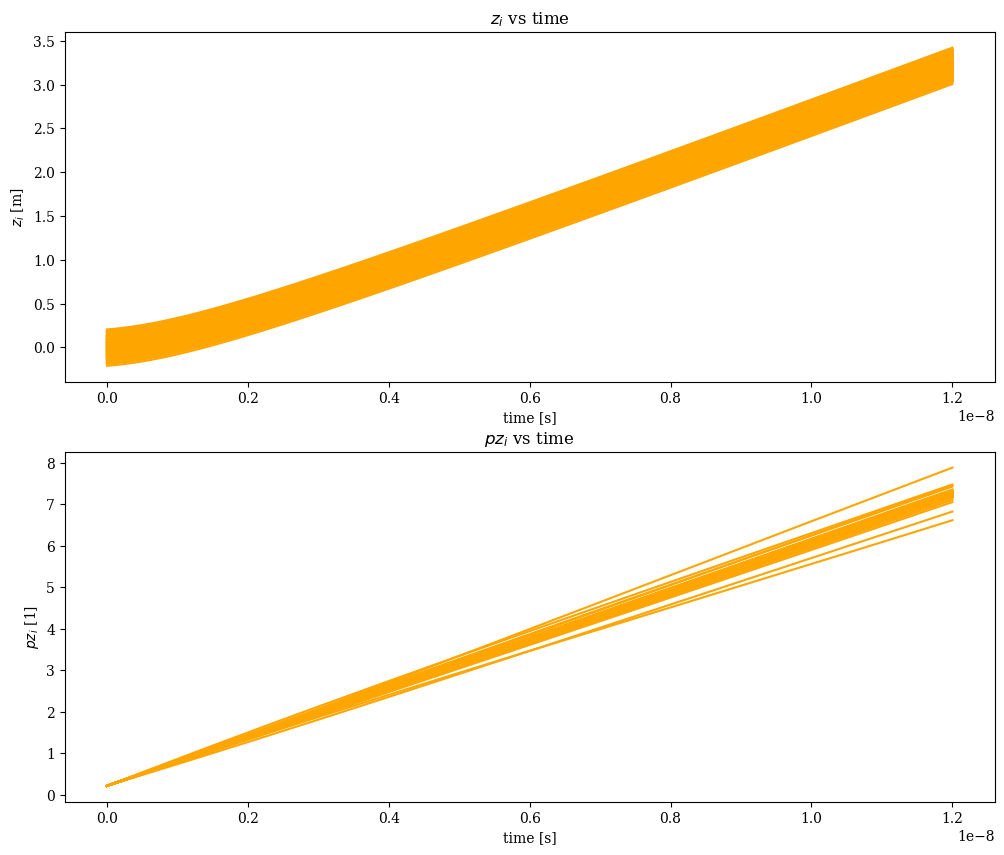

In [35]:
# Interpolate the perturbation onto a common time grid and add the
# zeroth-order solution.  Transverse zeroth-order position and momentum
# are zero by construction (only the longitudinal external field acts).
num_targets = len(r1_t_particles)
times = np.linspace(0.0, T_END_SIMPLE, 100)

r_t_particles = np.zeros((num_targets, len(times), 3))   # [m]
p_t_particles = np.zeros((num_targets, len(times), 3))   # [MeV/c]

for target_idx in range(num_targets):
    r0_0   = r0_particles[target_idx]
    times1 = times1_particles[target_idx]
    r1_t   = r1_t_particles[target_idx]
    p1_t   = p1_t_particles[target_idx]

    r1_x_interp = np.interp(times, times1, r1_t[0, :])
    r1_y_interp = np.interp(times, times1, r1_t[1, :])
    r1_z_interp = np.interp(times, times1, r1_t[2, :])
    p1_x_interp = np.interp(times, times1, p1_t[0, :])
    p1_y_interp = np.interp(times, times1, p1_t[1, :])
    p1_z_interp = np.interp(times, times1, p1_t[2, :])

    for t_idx, t in enumerate(times):
        r0, pz0, _ = get_0th_trajectory(t, r0_0, pz_0)
        r_t_particles[target_idx, t_idx, 0] = r0[0] + r1_x_interp[t_idx]
        r_t_particles[target_idx, t_idx, 1] = r0[1] + r1_y_interp[t_idx]
        r_t_particles[target_idx, t_idx, 2] = r0[2] + r1_z_interp[t_idx]
        p_t_particles[target_idx, t_idx, 0] = 0.0 + p1_x_interp[t_idx]
        p_t_particles[target_idx, t_idx, 1] = 0.0 + p1_y_interp[t_idx]
        p_t_particles[target_idx, t_idx, 2] = pz0 + p1_z_interp[t_idx]

fig, axes = plt.subplots(2, figsize=(12, 10))
for i in range(num_targets):
    axes[0].plot(times, r_t_particles[i, :, 2],                 color='orange')
    axes[1].plot(times, p_to_betagamma(p_t_particles[i, :, 2]), color='orange')
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("$z_i$ [m]")
axes[0].set_title("$z_i$ vs time")

axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("$pz_i$ [1]")
axes[1].set_title("$pz_i$ vs time")


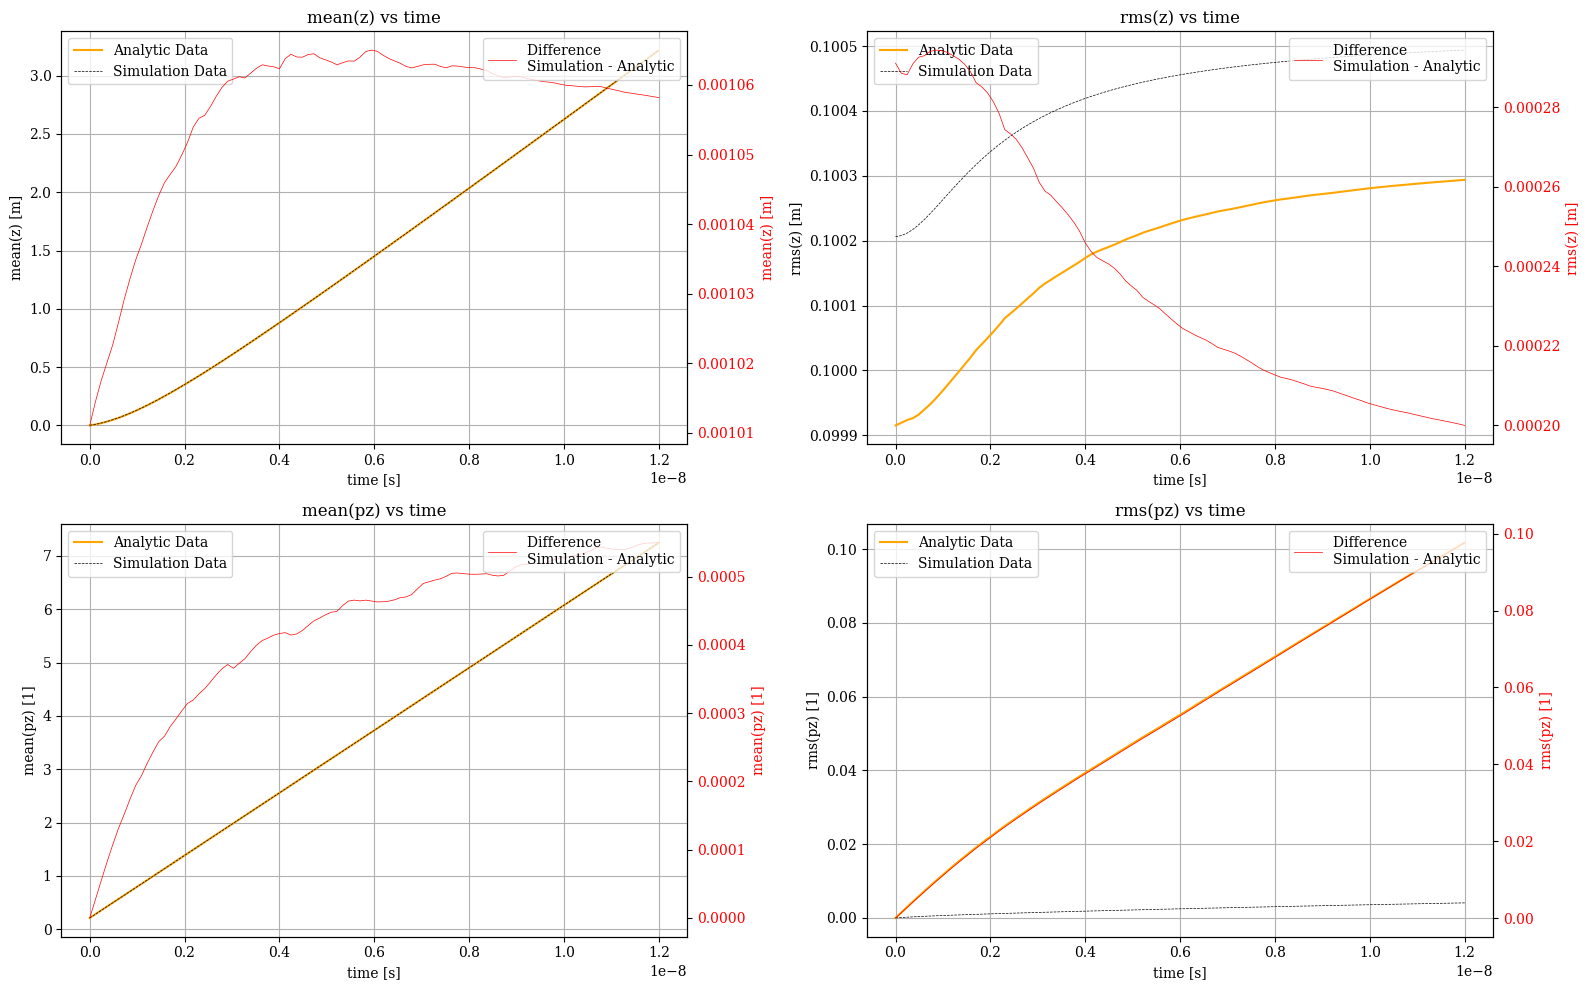

In [ ]:
mean_r_t = np.mean(r_t_particles, axis=0)
rms_r_t  = np.std(r_t_particles,  axis=0)
mean_p_t = np.mean(p_t_particles, axis=0)
rms_p_t  = np.std(p_t_particles,  axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Position plots

axes[0,0].plot(times, mean_r_t[:, 2], color='orange', label='Analytic Data')
axes[0,0].set_xlabel('time [s]')
axes[0,0].set_ylabel('mean(z) [m]')
axes[0,0].set_title('mean(z) vs time')
axes[0,0].legend()
axes[0,0].grid()
plot_data(axes[0,0], times, mean_r_t[:,2], data_times, data_position_means_si[:,2])

axes[0,1].plot(times, rms_r_t[:, 2], color='orange', label='Analytic Data')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('rms(z) [m]')
axes[0,1].set_title('rms(z) vs time')
axes[0,1].legend()
axes[0,1].grid()
plot_data(axes[0,1], times, rms_r_t[:,2], data_times, data_position_sigmas_si[:,2])


## Momentum plots

axes[1,0].plot(times, p_to_betagamma(mean_p_t[:, 2]), color='orange', label='Analytic Data')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('mean(pz) [1]')
axes[1,0].set_title('mean(pz) vs time')
axes[1,0].legend()
axes[1,0].grid()
plot_data(axes[1,0], times, p_to_betagamma(mean_p_t[:, 2]), data_times, p_to_betagamma(data_momentum_means_pp[:,2]))

axes[1,1].plot(times, p_to_betagamma(rms_p_t[:, 2]), color='orange', label='Analytic Data')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('rms(pz) [1]')
axes[1,1].set_title('rms(pz) vs time')
axes[1,1].legend()
axes[1,1].grid()
plot_data(axes[1,1], times, p_to_betagamma(rms_p_t[:, 2]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:,2]))

fig.tight_layout()